<a href="https://colab.research.google.com/github/princesspretty-b/masai_assignments/blob/main/ml-leakage-pipeline-bhuvaneshwari/Regression_Predicting_Values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1

Create a synthetic dataset with at least 50 records containing:

  Features:
    area_sqft
    num_bedrooms
    age_years
  Target column:
    price_lakhs
    
Build a multiple linear regression model using scikit-learn, print the intercept and each feature's coefficient, and display the first five actual vs. predicted values.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# Set seed for reproducibility
np.random.seed(42)

# Create synthetic dataset (50+ records)
n = 60
area_sqft = np.random.randint(500, 3000, n)
num_bedrooms = np.random.randint(1, 5, n)
age_years = np.random.randint(0, 30, n)

# Create target with some realistic relationship + noise
price_lakhs = (
    area_sqft * 0.05 +
    num_bedrooms * 10 -
    age_years * 0.8 +
    np.random.normal(0, 5, n)
)

# Create DataFrame
df = pd.DataFrame({
    "area_sqft": area_sqft,
    "num_bedrooms": num_bedrooms,
    "age_years": age_years,
    "price_lakhs": price_lakhs
})

# Features and target
X = df[["area_sqft", "num_bedrooms", "age_years"]]
y = df["price_lakhs"]

# Train model
model = LinearRegression()
model.fit(X, y)

# Print intercept and coefficients
print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

# Predictions
y_pred = model.predict(X)

# Display first 5 actual vs predicted
results = pd.DataFrame({
    "Actual": y.head(),
    "Predicted": y_pred[:5]
})
print("\nFirst 5 Actual vs Predicted:")
print(results)

Intercept: -3.5830673530376203
Coefficients:
area_sqft: 0.051486235486940084
num_bedrooms: 9.965069427516198
age_years: -0.7457972921276603

First 5 Actual vs Predicted:
       Actual   Predicted
0   86.673714   85.622554
1  104.923268  108.713378
2   87.426177   89.082676
3   95.156296  101.990216
4  107.579597  110.017103


Task 2

Evaluate your model using MAE, RMSE, and R². Print all three metrics. Then write a comment in your code (2–3 lines) explaining what each metric value tells you about your model's performance.

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Metrics
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("\nModel Evaluation Metrics:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Explanation:
# MAE shows the average absolute error in predictions (in lakhs), giving a simple interpretation of error size.
# RMSE penalizes larger errors more heavily, so it highlights if big mistakes exist in predictions.
# R² indicates how much variance in house prices is explained by the model (closer to 1 means better fit).


Model Evaluation Metrics:
MAE: 3.796985678627789
RMSE: 4.8636152484305
R²: 0.9838268957118724


Task 3

Compute the residuals for all predictions. Plot a histogram of residuals using Matplotlib. Add a title and axis labels. Below the plot, write a markdown cell (or a comment) explaining what a residual is and what the shape of your histogram suggests about your model.

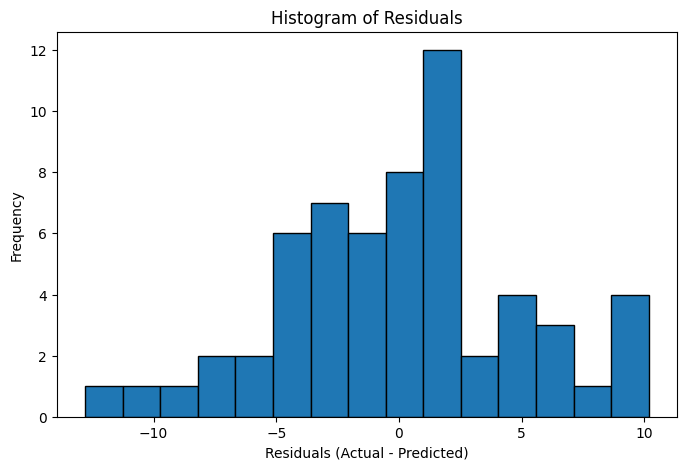

In [3]:
import matplotlib.pyplot as plt

# Compute residuals
residuals = y - y_pred

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=15, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

Explanation:
*   A residual is the difference between the actual value and the predicted value.
*   Ideally, residuals should be normally distributed around zero.
*   A roughly symmetric, bell-shaped histogram suggests the model is unbiased,
*   while skewness or extreme spread may indicate model errors or missing variables.